In [1]:
print("Hello World")
print("Bye")

Hello World
Bye


In [1]:
import pennylane as qp
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

def make_8qubit_operator(target_qubit, pauli_matrix):
    '''
    constructs a 256x356 matrix where 'pauli_matrix' acts on 'target_qubit'
    and identity acts on all others (?)
    '''
    #start with first qubit (index 0)
    I  = np.array([
        [1+0j, 0+0j],
        [0+0j, 1+0j]
    ], dtype=np.complex128)
    op = pauli_matrix if target_qubit == 0 else I
 
    #chain the remaining 7 qubits using Kronecker products
    for qubit in range(1,8):
        next_matrix = pauli_matrix if target_qubit == qubit else I
        op = np.kron(op, next_matrix)
    return op

def make_n_operator(qubit_index):
    #identity matrix 2x2
    I  = np.array([
        [1+0j, 0+0j],
        [0+0j, 1+0j]
    ], dtype=np.complex128)
    #pauli-Z matrix 2x2
    Z = np.array([
        [1+0j, 0+0j],
        [0+0j, -1+0j]
    ], dtype=np.complex128)

    n_x = 0.5 * (make_8qubit_operator(qubit_index,I) - make_8qubit_operator(qubit_index, Z))
    return n_x

print("check")
datasets = qp.data.load("qspin", sysname="FermiHubbard", periodicity="closed", lattice="kagome", layout="1x1", attributes=["ground_energies", "hamiltonians"])
print("Amount of datasets: ", len(datasets))
p1 = datasets[0]
available_hamiltonians = p1.hamiltonians
available_ground_energies = p1.ground_energies
print("Amount of hamiltonians in each dataset:", len(available_hamiltonians))
hamiltonian_deconstruct = available_hamiltonians[49]

hamiltonian_deconstruct.parameters[19] = np.complex128(4.0 + 0j)

#print("Hamiltonian 50: \n", hamiltonian_deconstruct)
#print("\nHamiltonian 50, Linear Combination Deconstructed:\n")
#print("\nCoeffs: \n", hamiltonian_deconstruct.coeffs)
#print("\nNon-editable hyper parameters: \n", hamiltonian_deconstruct.hyperparameters)
#print("\nEditable parameters: \n", hamiltonian_deconstruct.parameters)

#identity matrix 2x2
I2  = np.array([
    [1+0j, 0+0j],
    [0+0j, 1+0j]
], dtype=np.complex128)
#pauli-Z matrix 2x2
Z2 = np.array([
    [1+0j, 0+0j],
    [0+0j, -1+0j]
], dtype=np.complex128)
#number operators 
n_0 = make_n_operator(0)
n_1 = make_n_operator(1)
n_2 = make_n_operator(2)
n_3 = make_n_operator(3)
n_4 = make_n_operator(4)
n_5 = make_n_operator(5)
n_6 = make_n_operator(6)
n_7 = make_n_operator(7)
#double occupancy matrix O for site 0 is matrix product of both -> only for site 0?
O_double_occupancy_0 = n_0 @ n_4
O_double_occupancy_1 = n_1 @ n_5
O_double_occupancy_2 = n_2 @ n_6
O_double_occupancy_3 = n_3 @ n_7

for t in range (0, 100, 1):
    #matrix_t = qp.matrix(available_hamiltonians[t])
    matrix_t = available_hamiltonians[t].sparse_matrix()
    #eigenvalues, _ = np.linalg.eigh(matrix_t)
    ground_eigenvalue, ground_eigenvector = sp.sparse.linalg.eigsh(matrix_t, k=1, which="SA")
    calculated_ground_state_energy = np.round(np.abs(ground_eigenvalue[0]), 7)
    
    #Double Occupancy
    O_double_occupancy_scalar = np.array([
        np.real(np.vdot(ground_eigenvector, O_double_occupancy_0 @ ground_eigenvector)), 
        np.real(np.vdot(ground_eigenvector, O_double_occupancy_1 @ ground_eigenvector)),
        np.real(np.vdot(ground_eigenvector, O_double_occupancy_2 @ ground_eigenvector)),
        np.real(np.vdot(ground_eigenvector, O_double_occupancy_3 @ ground_eigenvector))
    ]).reshape(2,2)

    #Charge Correlation
    #grouping for indexing
    site_charge_operators = [
        (n_0 + n_4),
        (n_1 + n_5),
        (n_2 + n_6),
        (n_3 + n_7)
    ]
    #initialization
    O_charge_correlation = np.zeros((4,4))
    #calculating charge correlation for all pairs (4x4)
    for i in range(4):
        for j in range(4):
            O_charge_pair = site_charge_operators[i] @ site_charge_operators[j]
            O_charge_correlation_ij = np.vdot(ground_eigenvector, O_charge_pair @ ground_eigenvector)
            O_charge_correlation[i,j] = np.real(O_charge_correlation_ij)
    

    #Spin-Spin Correlation
            #Local Spin Magnetization
            #O matrix for spin on Site 0
            #O_spin_0 = 0.25 * (Z2_4 - Z2_0)
            #Spin operator for Site 1
            #O_spin_1 = 0.25 * (Z2_5 - Z2_1)
            #Site 2
            #O_spin_2 = 0.25 * (Z2_6 - Z2_2)
            #Site 3
            #O_spin_3 = 0.25 * (Z2_7 - Z2_3)
            #O matrix for Spin-Spin Correlation between Site 0 and Site 1, charge correlation???
            #O_spin_correlation_01 = O_spin_0 @ O_spin_1
    O_spin_correlation = np.zeros((4,4))
    for i in range(4):
        for j in range(4):
            O_spin_i = 0.25 * (make_8qubit_operator(i+4, Z2) - make_8qubit_operator(i, Z2))
            O_spin_j = 0.25 * (make_8qubit_operator(j+4, Z2) - make_8qubit_operator(j, Z2))

            O_pair = O_spin_i @ O_spin_j
            O_spin_correlation_ij = np.vdot(ground_eigenvector, O_pair @ ground_eigenvector)
            O_spin_correlation[i,j] = np.real(O_spin_correlation_ij)


    #S(q)
    q_values = np.array([0, np.pi/2, np.pi, 3*np.pi/2])

    S_q = []
    #fourier transform
    for q in q_values:
        sq_val = 0.0
        for j in range(4):
            for k in range(4):
                #angular phase factor e^(-i * q * (j - k))
                phase = np.exp(-1j * q * (j - k))
                sq_val += phase * O_spin_correlation[j,k]
        #S_q.append(np.real(sq_val)/L) #S_q = 1/L * summation of phase * matching O_spin_correlation factor
    #plotting (?)
    #plt.figure(figsize=(6,4.5))
    #plt.plot(q_values, S_q)
   # plt.title("Spin Structure Factor $S(q)$ for $L=4$, Matrix ", t, "found

    
    #physical property value (inner product?)
    #property_matrix = O_spin_correlation @ ground_eigenvector
    #spin_correlation_value = np.vdot(ground_eigenvector, property_matrix)

    #print("Matrix ", t, ", ground eigenvector:\n", ground_eigenvector)
    #print("Matrix ", t, ":")
    print("Hamiltonian ", t, ": \n", available_hamiltonians[t])
    print("Ground State Energy: \n", calculated_ground_state_energy)
    #print("Double Occupancy = \n", O_double_occupancy_scalar)
    #print("Charge Correlation matrix = \n", O_charge_correlation)
    #print("Spin-Spin Correlation <Sz_0, Sz_1> = \n", O_spin_correlation)
    #print("Spin-Spin Correlation <Sz+0, Sz_1> = ", np.real(spin_correlation_value))

    '''
    To Implement Tomorrow:

    # 1. BUILD EVERYTHING THAT IS NOT AFFECTED (Outside all loops)
n_0 = make_n_operator(0)
# ... build all other spin and charge operators here ...

for t in range(100):  # Outer parameter loop
    
    # Initialize blank arrays to accumulate TABC averages
    tabc_energy = 0
    tabc_double_occ = np.zeros((2,2))
    tabc_charge_corr = np.zeros((4,4))
    tabc_spin_corr = np.zeros((4,4))
    
    for theta in twist_angles:  # Inner TABC Loop
        # 2. CALCULATE WHAT IS AFFECTED BY TABC
        # - Generate twisted Hamiltonian matrix_t(theta)
        # - Compute new ground_eigenvector
        # - Evaluate np.vdot() using your pre-built operators
        
        # - Accumulate results into your tabc_ variables
        
    # 3. AVERAGE THE RESULTS
    # - Divide your accumulated variables by len(twist_angles)
    # - Print your final TABC-averaged parameters
    '''
 



check


ValueError: No datasets exist for the provided configuration.
Please check the available datasets by using the ``qp.data.list_datasets()`` function.

Help on function fermi_hubbard in module pennylane.spin.spin_hamiltonian:

fermi_hubbard(lattice, n_cells, hopping=1.0, coulomb=1.0, boundary_condition=False, neighbour_order=1, mapping='jordan_wigner')
    Generates the Hamiltonian for the Fermi-Hubbard model on a lattice.
    
    The Hamiltonian is represented as:
    
    .. math::
    
        \hat{H} = -t\sum_{<i,j>, \sigma} c_{i\sigma}^{\dagger}c_{j\sigma} + U\sum_{i}n_{i \uparrow} n_{i\downarrow}
    
    where :math:`t` is the hopping term representing the kinetic energy of electrons, :math:`U` is the
    on-site Coulomb interaction representing the repulsion between electrons, :math:`<i,j>` represents the
    indices of neighbouring spins, :math:`\sigma` is the spin degree of freedom, and
    :math:`n_{i \uparrow}, n_{i \downarrow}` are number operators for spin-up and spin-down fermions
    at site :math:`i`. This function assumes two fermions with opposite spins on each lattice
    site.
    
    Args:
        lattice (str)

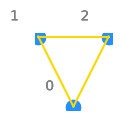

In [11]:
import matplotlib.pyplot as plt


qp.data.list_datasets()

n_cells = [1,1]
hopping = 1.0
onsite = 1.0
hamiltonian_kagome = qp.spin.fermi_hubbard('kagome', n_cells, hopping, onsite, True)
print(help(qp.spin.fermi_hubbard))
print(f"Hamiltonian Kagome: \n{hamiltonian_kagome}")

kagome_matrix = hamiltonian_kagome.sparse_matrix()
kagome_energy, __ = sp.sparse.linalg.eigsh(kagome_matrix, k=1, which = "SA")
round_kagome_energy = np.round(np.abs(kagome_energy[0]), 7)

print(f"Kagome Energy: \n{round_kagome_energy}")
def plot(lattice, figsize=None, showlabel=True):

    # initialize the plot
    if not figsize:
        figsize = lattice.n_cells[::-1]

    plt.figure(figsize=figsize)

    # get lattice nodes and edges and plot them
    nodes = lattice.lattice_points

    for edge in lattice.edges:
        start_index, end_index, color = edge
        start_pos, end_pos = nodes[start_index], nodes[end_index]

        x_axis = [start_pos[0], end_pos[0]]
        y_axis = [start_pos[1], end_pos[1]]
        plt.plot(x_axis, y_axis, color='gold')

        plt.scatter(nodes[:,0], nodes[:,1], color='dodgerblue', s=100)

        if showlabel:
            for index, pos in enumerate(nodes):
                plt.text(pos[0]-0.2, pos[1]+0.1, str(index), color='gray')

    plt.axis("off")
    plt.show()

lattice = qp.spin.generate_lattice('kagome', n_cells)
plot(lattice)

In [23]:
import pennylane as qp
import numpy as np
import quspin as qu
print("check")
datasets = qp.data.load("qspin", sysname="FermiHubbard", periodicity="open", lattice="rectangular", layout="2x2", attributes=["ground_energies", "hamiltonians"])
p1 = datasets[0]
available_hamiltonians = p1.hamiltonians
available_ground_energies = p1.ground_energies
hamiltonian_0 = available_hamiltonians[0]
print(hamiltonian_0)

#System parameters for quspin
L, N_up, N_down = 4, 2, 2
#L: 2x2 = 4 sites, 2 spin-up and 2 spin-down (??? will need to check)

t = 1.0 #hopping amplitude
U = 4.0 #on-site interaction strength 
    #will need to check from pennylane -- do the hamiltonians have different strengths?

#fermion basis with particle conservation symmetries (
basis = qu.basis.spinful_fermion_basis_1d(L, Nf=(N_up, N_down))

#hopping terms ??
hop_spin_up = [[-t, i, (i+1) %L] for i in range(L)]
hop_spin_down = [[-t ,i, (i+1) %L] for i in range(L)]

#interaction terms ??
interaction = [[U, i, i] for i in range(L)]

#format terms into quspin's operator string format, where:
#f means fermion annihilation/creation, + is creation, - is annihilation
#n means number operator

static_list = [
    ["+-|", hop_spin_up],
    ["-+|", [[t, i, (i + 1)%L] for i in range(L)]],
    ["|+-", hop_spin_down],
    ["|-+", [[t, i, (i+1)%L] for i in range(L)]],
    ["n|n", interaction],
]

#psarse hamiltonian
H = qu.operators.hamiltonian(static_list, [], basis=basis, dtype=np.float64)

#exact diagonalization for ground energy

ground_energy,_ = H.eigsh(k=1, which="SA")
print("Ground State Energy: \n", ground_energy)



check
(0.5+0j) * (Y(0) @ Y(1)) + (0.5+0j) * (X(0) @ X(1)) + (0.5+0j) * (Y(2) @ Y(1)) + (0.5+0j) * (X(2) @ X(1)) + (0.5+0j) * (Y(3) @ Y(2)) + (0.5+0j) * (X(3) @ X(2)) + (0.5+0j) * (Y(5) @ Y(4)) + (0.5+0j) * (X(5) @ X(4)) + (0.5+0j) * (Y(6) @ Y(5)) + (0.5+0j) * (X(6) @ X(5)) + (0.5+0j) * (Y(7) @ Y(6)) + (0.5+0j) * (X(7) @ X(6)) + 0j * (Z(0) @ Z(4)) + 0j * (Z(1) @ Z(5)) + 0j * (Z(2) @ Z(6)) + 0j * (Z(3) @ Z(7))
Hermiticity check passed!
Symmetry checks passed!
Particle conservation check passed!
Ground State Energy: 
 [-2.10274848]


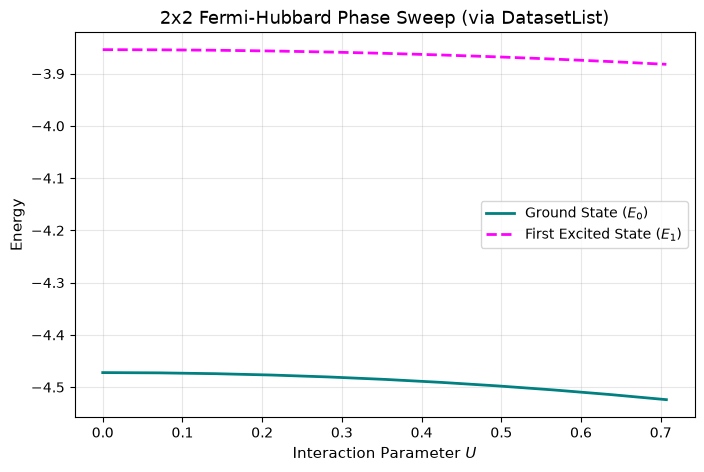

In [19]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'check' is your dataset object
#U_vals = check['parameters']['U']
#ham_list = check['hamiltonians']  # This is your DatasetList
datasets = qp.data.load("qspin", sysname="FermiHubbard", periodicity="open", lattice="rectangular", layout="2x2")
p1 = datasets[0]
ham_list = p1.hamiltonians

ground_energies = []
excited_energies = []
qspin = []

# Loop directly through PennyLane's DatasetList
for H in ham_list:
    # Convert each PennyLane Hamiltonian object to a dense matrix
    H_matrix = qml.matrix(H)
    # Compute the eigenvalues (sorted lowest to highest)
    eigenvalues = np.linalg.eigvalsh(H_matrix)
    
    ground_energies.append(eigenvalues[0])
    excited_energies.append(eigenvalues[1])

# Just in case the lengths mismatch due to an incomplete download slice
num_points = min(len(U_vals), len(ground_energies))

# Plotting the data
plt.figure(figsize=(8, 5))
plt.plot(U_vals[:num_points], ground_energies[:num_points], label="Ground State ($E_0$)", color="teal", lw=2)
plt.plot(U_vals[:num_points], excited_energies[:num_points], label="First Excited State ($E_1$)", color="magenta", linestyle="--", lw=2)

plt.title("2x2 Fermi-Hubbard Phase Sweep (via DatasetList)", fontsize=13)
plt.xlabel("Interaction Parameter $U$", fontsize=11)
plt.ylabel("Energy", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
import pennylane as qp
import scipy as sp
import numpy as np

n_cells = [2,2]
t = 1.0
u = 6.082
#print(help(qp.spin.fermi_hubbard))

spin_ham = qp.spin.fermi_hubbard("kagome", n_cells, hopping=t, coulomb=u, boundary_condition=True)
matrix_t = spin_ham.sparse_matrix()
ground_eigenvalue, ground_eigenvector = sp.sparse.linalg.eigsh(matrix_t, k=1, which="SA")
print(f"Energy: {ground_eigenvalue}")
matrix_t = qp.matrix(spin_ham)   
eigenvalues, _ = np.linalg.eigh(matrix_t)
print(f"Energies:\n{eigenvalues}")

Energy: [-14.85648314]


MemoryError: Unable to allocate 4.00 PiB for an array with shape (16777216, 16777216) and data type complex128